<h1>Value Iteration using the Bellman Optimality Equation for the FrozenLake MDP </h1>

In [ ]:
%matplotlib inline
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
seed=0
gamma=0.95 #discount factor
num_iter=10 #num of interations
random.seed(seed)
np.random.seed(seed) 
env=gym.make('FrozenLake-v1')
env.reset(seed=seed)

(0, {'prob': 1})

In [15]:
import numpy as np
import matplotlib.pyplot as plt

ARROWS = np.array(['←','↓','→','↑'])

def render_value_and_policy(desc, V_row, pi_row, title=""):
    """
    desc: env.unwrapped.desc (bytes) shape (nrow,ncol)
    V_row: shape (nS,) values for one iteration
    pi_row: shape (nS,) action indices for one iteration
    """
    nrow, ncol = desc.shape
    gridV = V_row.reshape(nrow, ncol)
    gridA = pi_row.reshape(nrow, ncol)

    # decode map bytes -> chars like 'S','F','H','G'
    tiles = np.vectorize(lambda x: x.decode("utf-8") if isinstance(x, (bytes, np.bytes_)) else str(x))(desc)

    # Policy arrows, but hide arrows on terminal tiles (H, G) for clarity
    arrows = ARROWS[gridA].astype(object)
    arrows[tiles == 'H'] = 'H'
    arrows[tiles == 'G'] = 'G'
    arrows[tiles == 'S'] = 'S'   # optional: keep S visible
    arrows[tiles == 'F'] = ARROWS[gridA][tiles == 'F']

    plt.figure(figsize=(5, 5))
    plt.imshow(gridV)  # don't set colors manually
    plt.colorbar()
    plt.title(title)

    # annotate each cell with tile + arrow + value
    for r in range(nrow):
        for c in range(ncol):
            txt = f"{tiles[r,c]}\n{arrows[r,c]}\n{gridV[r,c]:.2f}"
            plt.text(c, r, txt, ha='center', va='center', fontsize=10)

    plt.xticks(range(ncol))
    plt.yticks(range(nrow))
    plt.grid(False)
    plt.show()


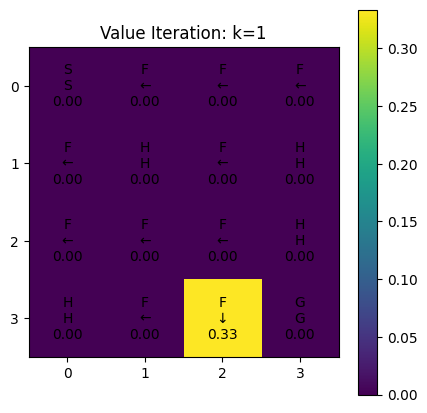

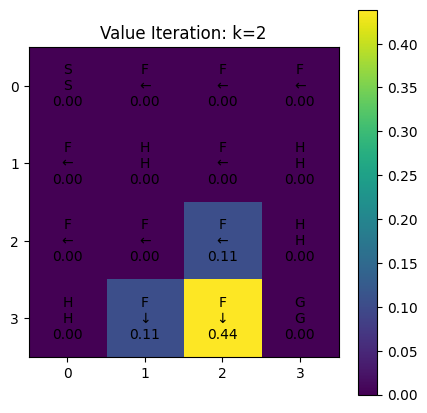

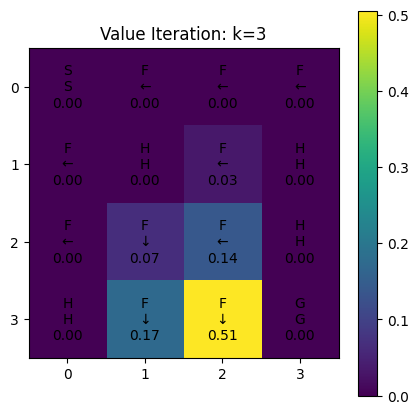

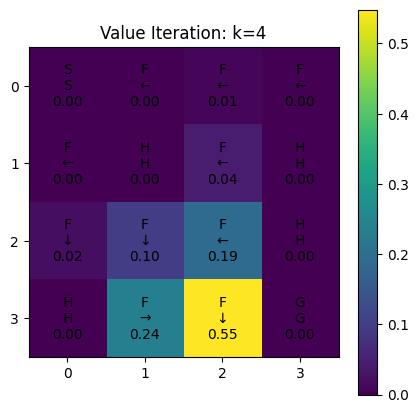

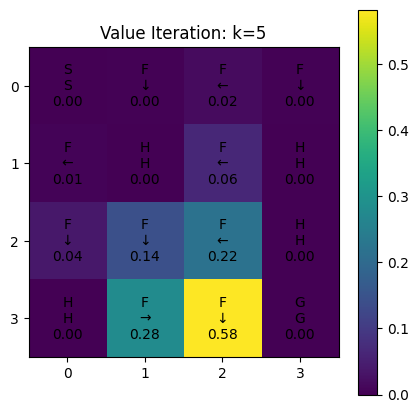

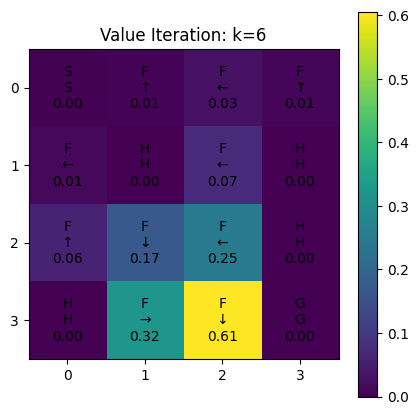

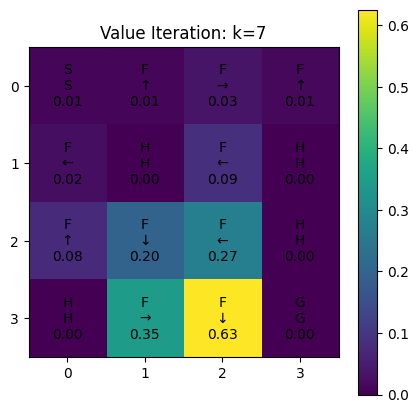

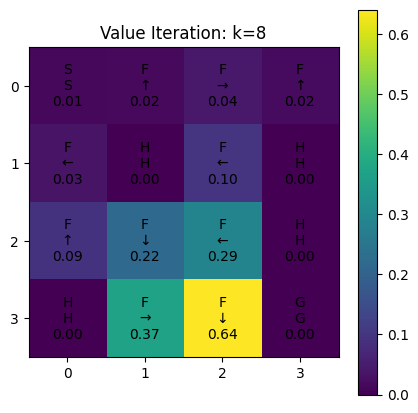

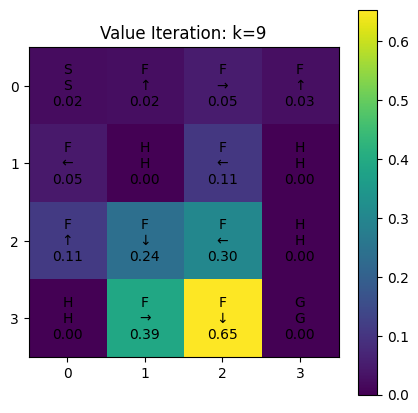

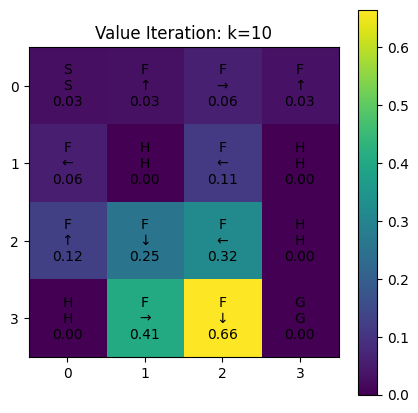

In [17]:
def value_iteration(env,gamma,num_iter,viz_every):
    desc = env.unwrapped.desc              # map (bytes array)
    P = env.unwrapped.P                    # transition model
    num_states = env.observation_space.n
    num_actions = env.action_space.n

    V=np.zeros((num_iter+1,num_states))
    Q=np.zeros((num_iter+1,num_states,num_actions))
    pi=np.zeros((num_iter+1,num_states),dtype=int)
    

    for k in range(1,num_iter+1):
        for s in range(num_states):
            for a in range(num_actions):
                #calculate  every possible next states' and calculate the expected value for that action
                q_sa=0
                for (pr,nextstate,reward,terminated) in P[s][a]:
                    q_sa+=pr*(reward+gamma*V[k-1,nextstate])
                Q[k,s,a]=q_sa
            V[k,s]=np.max(Q[k,s,:])
            pi[k,s]=np.argmax(Q[k,s,:])
        if (k % viz_every) == 0:
            render_value_and_policy(desc, V[k], pi[k], title=f"Value Iteration: k={k}")
    return V,Q,pi,desc
V,Q,pi,desc=value_iteration(env,gamma,num_iter,viz_every=1)

    
